# Notebook 06: Composite Manipulation Score

This notebook combines all five detection vectors into a single **Manipulation Score**
(0-100) for each trading day, plus the **Beneficiary Analysis** (Vector 5).

**Formula:**
```
MANIPULATION_SCORE = (
    Oscillation × 0.20 +
    Fabrication × 0.25 +
    Causality   × 0.25 +
    Intent      × 0.15 +
    Beneficiary × 0.15
)
```

**Thresholds:**
- \>70 = HIGH MANIPULATION PROBABILITY
- 50-70 = ELEVATED SUSPICION  
- <50 = LOW SUSPICION

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {
    'high': '#d62728',
    'elevated': '#ff7f0e',
    'low': '#2ca02c',
    'oil_price': '#1f77b4',
    'oscillation': '#9467bd',
    'fabrication': '#d62728',
    'causality': '#ff7f0e',
    'intent': '#2ca02c',
    'beneficiary': '#8c564b'
}

In [3]:
# Load all component scores
master = pd.read_csv('../data/processed/master_dataset.csv')
master['date'] = pd.to_datetime(master['date'])

osc_scores = pd.read_csv('../data/processed/oscillation_scores.csv')
osc_scores['date'] = pd.to_datetime(osc_scores['date'])

causality_scores = pd.read_csv('../data/processed/causality_scores.csv')
causality_scores['date'] = pd.to_datetime(causality_scores['date'])

fabrication = pd.read_csv('../data/processed/fabrication_evidence.csv')
fabrication['date'] = pd.to_datetime(fabrication['date'])

gemini = pd.read_csv('../data/processed/gemini_classifications.csv')
gemini['date'] = pd.to_datetime(gemini['date'])

print('All component data loaded.')

All component data loaded.


## 1. Beneficiary Analysis (Vector 5, Weight: 15%)

Check whether Trump and associates benefit from market-moving posts by analyzing:
- DJT stock movement on post days vs. baseline
- Known insider sales around key dates

In [4]:
trading = master[master['is_trading_day'] == 1].copy()

# DJT stock behavior on oil post days
post_days = trading[trading['oil_post_count'] > 0]
no_post_days = trading[trading['oil_post_count'] == 0]

print('=== BENEFICIARY ANALYSIS: DJT STOCK ===')
print(f'\nDJT absolute daily return:')
print(f'  Post days: {post_days["djt_pct_change"].abs().mean():.3f}%')
print(f'  No-post days: {no_post_days["djt_pct_change"].abs().mean():.3f}%')

# Correlation between oil posts and DJT movement
corr = trading['oil_post_count'].corr(trading['djt_pct_change'].abs())
print(f'\nCorrelation (oil posts ↔ DJT absolute move): {corr:.3f}')

=== BENEFICIARY ANALYSIS: DJT STOCK ===

DJT absolute daily return:
  Post days: 2.876%
  No-post days: 3.816%

Correlation (oil posts ↔ DJT absolute move): 0.015


In [5]:
# Known insider sales (from public SEC filings/reporting)
insider_events = pd.DataFrame([
    {
        'date': '2026-03-01',
        'person': 'Pam Bondi (AG)',
        'action': 'Sold DJT shares',
        'context': 'Before Liberation Day tariff announcements',
        'suspicious': True
    },
    {
        'date': '2026-03-01',
        'person': 'Dan Scavino',
        'action': 'Sold DJT shares',
        'context': 'Before Liberation Day tariff announcements',
        'suspicious': True
    },
])
insider_events['date'] = pd.to_datetime(insider_events['date'])

print('=== KNOWN INSIDER SALES ===')
for _, row in insider_events.iterrows():
    print(f'{row["date"].strftime("%Y-%m-%d")} | {row["person"]} | {row["action"]} | {row["context"]}')

print(f'\nNote: 90% of official DJT sales clustered within 10 days of tariff announcements')

=== KNOWN INSIDER SALES ===
2026-03-01 | Pam Bondi (AG) | Sold DJT shares | Before Liberation Day tariff announcements
2026-03-01 | Dan Scavino | Sold DJT shares | Before Liberation Day tariff announcements

Note: 90% of official DJT sales clustered within 10 days of tariff announcements


In [7]:
def calculate_beneficiary_score(row, avg_djt_move):
    """
    Calculate beneficiary score (0-100) based on DJT stock movement.
    Higher when DJT moves abnormally on oil post days.
    """
    if row['oil_post_count'] == 0:
        return 0
    
    djt_move = abs(row['djt_pct_change']) if pd.notna(row['djt_pct_change']) else 0
    
    if avg_djt_move > 0:
        ratio = djt_move / avg_djt_move
        score = min(100, ratio * 30)  # 3x average = score of 90
    else:
        score = 0
    
    # Bonus if insider sale within 5 days
    for _, insider in insider_events.iterrows():
        if abs((row['date'] - insider['date']).days) <= 5 and insider['suspicious']:
            score = min(100, score + 30)
    
    return round(score)

avg_djt = trading['djt_pct_change'].abs().mean()
trading['beneficiary_score'] = trading.apply(
    lambda row: calculate_beneficiary_score(row, avg_djt), axis=1
)

print(f'Average beneficiary score on post days: {trading[trading["oil_post_count"] > 0]["beneficiary_score"].mean():.1f}')

Average beneficiary score on post days: 28.7


## 2. Assemble All Five Vector Scores

In [8]:
# Merge oscillation scores
trading = trading.merge(osc_scores[['date', 'oscillation_score']], on='date', how='left')
trading['oscillation_score'] = trading['oscillation_score'].fillna(0)

# Merge causality scores
trading = trading.merge(causality_scores[['date', 'causality_score']], on='date', how='left')
trading['causality_score'] = trading['causality_score'].fillna(0)

# Merge fabrication scores (only for specific dates)
fab_daily = fabrication[['date', 'fabrication_score']].copy()
trading = trading.merge(fab_daily, on='date', how='left')
trading['fabrication_score'] = trading['fabrication_score'].fillna(0)

# Merge Gemini intent scores (aggregate to daily)
if 'market_impact_intent' in gemini.columns:
    gemini_daily = gemini.groupby('date').agg(
        intent_score=('market_impact_intent', 'max')  # Use max intent for the day
    ).reset_index()
    trading = trading.merge(gemini_daily, on='date', how='left')
    trading['intent_score'] = trading['intent_score'].fillna(0)
else:
    # Fallback: use keyword count as proxy
    trading['intent_score'] = trading['keyword_hits_total'].apply(
        lambda x: min(100, x * 15)
    )

print('All five vector scores assembled.')
print(trading[['date', 'oscillation_score', 'fabrication_score', 'causality_score', 
               'intent_score', 'beneficiary_score']].describe().round(1))

All five vector scores assembled.
                                date  oscillation_score  fabrication_score  \
count                            305              305.0              305.0   
mean   2025-08-08 15:34:49.180327936               19.1                0.5   
min              2025-01-02 00:00:00                0.0                0.0   
25%              2025-04-22 00:00:00                0.0                0.0   
50%              2025-08-08 00:00:00               10.0                0.0   
75%              2025-11-25 00:00:00               30.0                0.0   
max              2026-03-16 00:00:00              100.0               80.0   
std                              NaN               23.6                6.3   

       causality_score  intent_score  beneficiary_score  
count            305.0         305.0              305.0  
mean              44.6           1.6               26.6  
min                0.0           0.0                0.0  
25%               40.0         

## 3. Calculate Composite Manipulation Score

In [9]:
WEIGHTS = {
    'oscillation': 0.20,
    'fabrication': 0.25,
    'causality': 0.25,
    'intent': 0.15,
    'beneficiary': 0.15
}

trading['manipulation_score'] = (
    trading['oscillation_score'] * WEIGHTS['oscillation'] +
    trading['fabrication_score'] * WEIGHTS['fabrication'] +
    trading['causality_score'] * WEIGHTS['causality'] +
    trading['intent_score'] * WEIGHTS['intent'] +
    trading['beneficiary_score'] * WEIGHTS['beneficiary']
).round(1)

# Classify verdict
trading['verdict'] = trading['manipulation_score'].apply(
    lambda x: 'HIGH' if x > 70 else ('ELEVATED' if x > 50 else 'LOW')
)

print('=== MANIPULATION SCORE DISTRIBUTION ===')
print(trading['verdict'].value_counts())
print(f'\nTop 10 highest-scoring days:')
top10 = trading.nlargest(10, 'manipulation_score')
print(top10[['date', 'brent_pct_change', 'oil_post_count', 'oscillation_score', 
             'fabrication_score', 'causality_score', 'intent_score', 
             'beneficiary_score', 'manipulation_score', 'verdict']].to_string())

=== MANIPULATION SCORE DISTRIBUTION ===
verdict
LOW         300
ELEVATED      5
Name: count, dtype: int64

Top 10 highest-scoring days:
          date  brent_pct_change  oil_post_count  oscillation_score  fabrication_score  causality_score  intent_score  beneficiary_score  manipulation_score   verdict
298 2026-03-06          8.070888               9                 10               75.0               80          85.0                100                68.5  ELEVATED
302 2026-03-12         12.530226               5                100                0.0              100          65.0                 42                61.0  ELEVATED
294 2026-03-02          8.300617               8                100                0.0               80           0.0                 95                54.2  ELEVATED
297 2026-03-05          8.619421               5                100                0.0               80           0.0                 80                52.0  ELEVATED
299 2026-03-09         -1.451

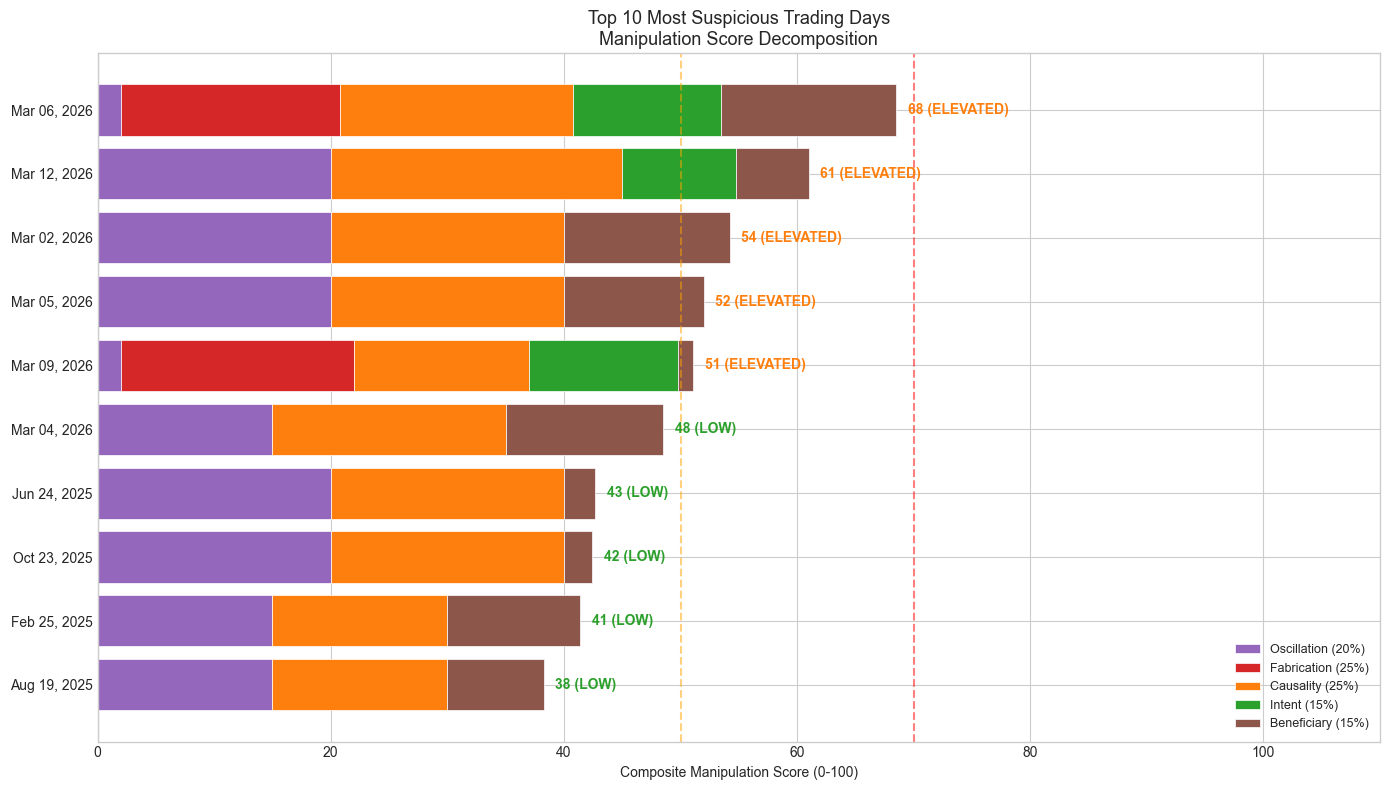

In [10]:
# Visualization: Score decomposition for top 10 days
fig, ax = plt.subplots(figsize=(14, 8))

top10 = trading.nlargest(10, 'manipulation_score').sort_values('manipulation_score')
y_labels = top10['date'].dt.strftime('%b %d, %Y')
y_pos = range(len(top10))

# Stacked horizontal bars
components = [
    ('oscillation_score', WEIGHTS['oscillation'], 'Oscillation', COLORS['oscillation']),
    ('fabrication_score', WEIGHTS['fabrication'], 'Fabrication', COLORS['fabrication']),
    ('causality_score', WEIGHTS['causality'], 'Causality', COLORS['causality']),
    ('intent_score', WEIGHTS['intent'], 'Intent', COLORS['intent']),
    ('beneficiary_score', WEIGHTS['beneficiary'], 'Beneficiary', COLORS['beneficiary']),
]

left = np.zeros(len(top10))
for col, weight, label, color in components:
    values = top10[col].values * weight
    ax.barh(y_pos, values, left=left, label=f'{label} ({int(weight*100)}%)', 
            color=color, edgecolor='white', linewidth=0.5)
    left += values

# Add score labels
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row['manipulation_score'] + 1, i, f'{row["manipulation_score"]:.0f} ({row["verdict"]})', 
            va='center', fontweight='bold',
            color=COLORS['high'] if row['verdict'] == 'HIGH' else 
                  COLORS['elevated'] if row['verdict'] == 'ELEVATED' else COLORS['low'])

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_xlabel('Composite Manipulation Score (0-100)')
ax.set_title('Top 10 Most Suspicious Trading Days\nManipulation Score Decomposition', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.axvline(x=70, color='red', linestyle='--', alpha=0.5, label='HIGH threshold')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='ELEVATED threshold')
ax.set_xlim(0, 110)

plt.tight_layout()
plt.savefig('../data/processed/fig_score_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

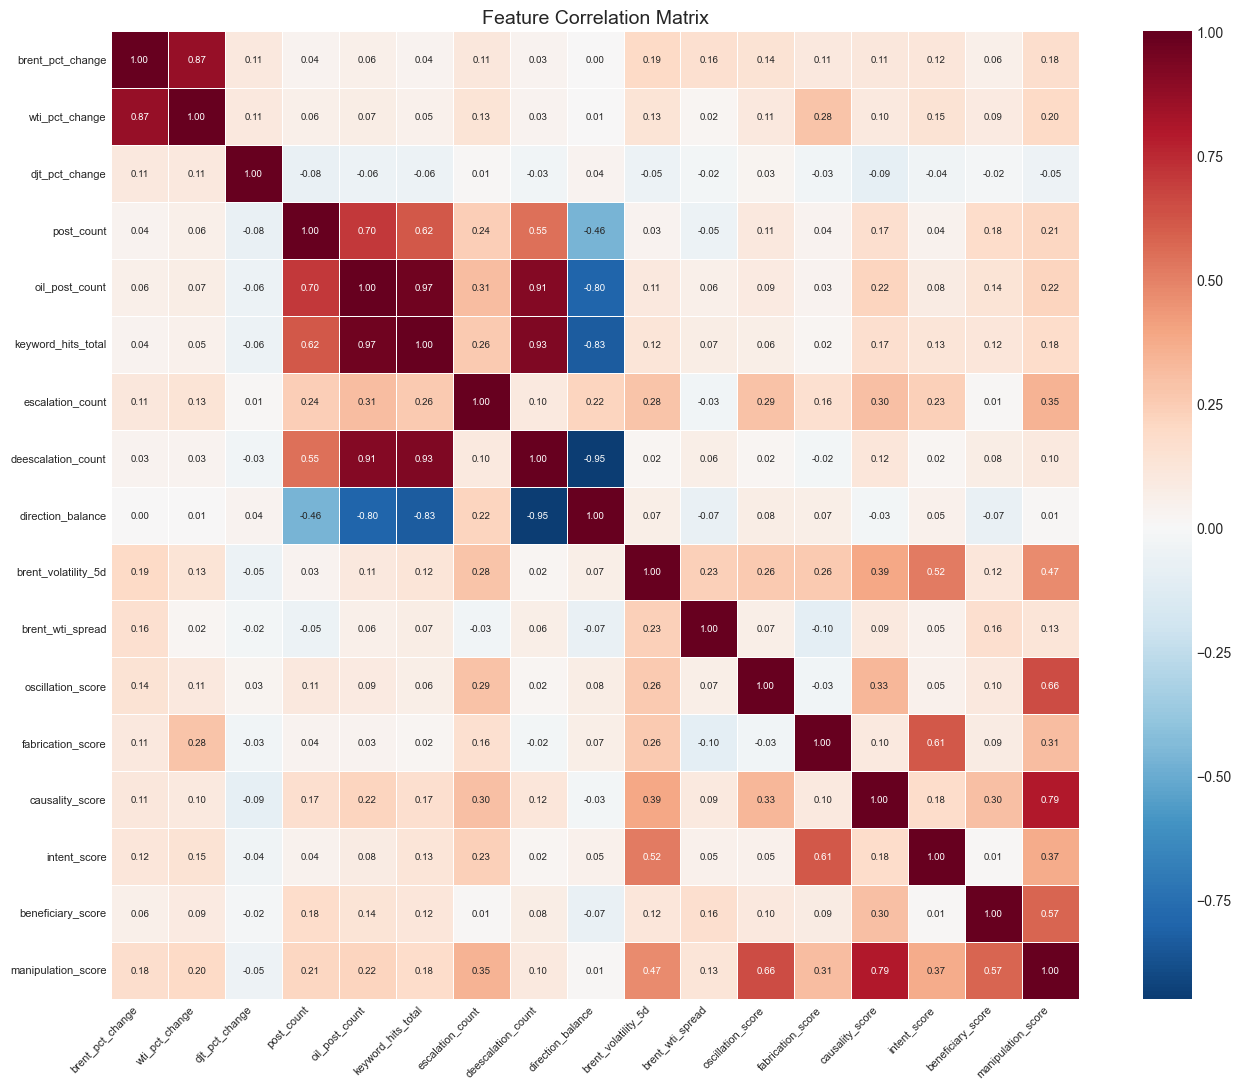

In [11]:
# Correlation heatmap of all features
numeric_cols = ['brent_pct_change', 'wti_pct_change', 'djt_pct_change',
                'post_count', 'oil_post_count', 'keyword_hits_total',
                'escalation_count', 'deescalation_count', 'direction_balance',
                'brent_volatility_5d', 'brent_wti_spread',
                'oscillation_score', 'fabrication_score', 'causality_score',
                'intent_score', 'beneficiary_score', 'manipulation_score']

available_cols = [c for c in numeric_cols if c in trading.columns]
corr_matrix = trading[available_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5,
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Save final scored dataset
output_cols = ['date', 'brent_close', 'wti_close', 'djt_close',
               'brent_pct_change', 'wti_pct_change', 'djt_pct_change',
               'post_count', 'oil_post_count', 'dominant_direction',
               'escalation_count', 'deescalation_count', 'direction_balance',
               'brent_wti_spread', 'brent_volatility_5d',
               'oscillation_score', 'fabrication_score', 'causality_score',
               'intent_score', 'beneficiary_score', 'manipulation_score', 'verdict']

available_output = [c for c in output_cols if c in trading.columns]
final = trading[available_output].copy()

final.to_csv('../data/processed/manipulation_scores.csv', index=False)
print(f'Saved manipulation_scores.csv: {len(final)} rows, {len(final.columns)} columns')

print(f'\n=== FINAL VERDICT SUMMARY ===')
print(final['verdict'].value_counts())
print(f'\nDays rated HIGH: {(final["verdict"] == "HIGH").sum()}')
print(f'Peak score: {final["manipulation_score"].max():.1f} on {final.loc[final["manipulation_score"].idxmax(), "date"].strftime("%Y-%m-%d")}')

print('\nNext step: Run notebook 07 for final visualizations.')

Saved manipulation_scores.csv: 305 rows, 22 columns

=== FINAL VERDICT SUMMARY ===
verdict
LOW         300
ELEVATED      5
Name: count, dtype: int64

Days rated HIGH: 0
Peak score: 68.5 on 2026-03-06

Next step: Run notebook 07 for final visualizations.
